# Dyna-Q on Taxi-v3

Compares pure Q-learning (n=0) vs Dyna-Q with n in {5, 10, 50} planning steps.

- Q-table: NumPy array of shape (500, 6)
- Model: Python dict storing `model[(s, a)] = (r, s')`
- Same Bellman target for direct RL and planning updates


In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


## Algorithm


In [2]:
def dyna_q(n_planning=0, max_steps=20000, alpha=0.1, gamma=0.95,
           eps=0.1, seed=0):
    env = gym.make("Taxi-v3")
    nS, nA = env.observation_space.n, env.action_space.n
    rng = np.random.default_rng(seed)

    Q = np.zeros((nS, nA))
    model = {}                      # model[(s,a)] = (r, s')
    rewards = np.zeros(max_steps)   # per-step real reward
    ep_lengths = []
    s, _ = env.reset(seed=seed)
    ep_len = 0

    for t in range(max_steps):
        # eps-greedy
        a = rng.integers(nA) if rng.random() < eps else int(np.argmax(Q[s]))
        ns, r, term, trunc, _ = env.step(a)

        # Direct RL
        target = r + (0 if term else gamma * Q[ns].max())
        Q[s, a] += alpha * (target - Q[s, a])

        # Model learning
        model[(s, a)] = (r, ns)

        # Planning: n simulated updates from previously visited (s,a)
        if n_planning and model:
            keys = list(model.keys())
            idx = rng.integers(len(keys), size=n_planning)
            for k in idx:
                ps, pa = keys[k]
                pr, pns = model[(ps, pa)]
                Q[ps, pa] += alpha * (pr + gamma * Q[pns].max() - Q[ps, pa])

        rewards[t] = r
        ep_len += 1
        if term or trunc:
            ep_lengths.append(ep_len)
            ep_len = 0
            s, _ = env.reset()
        else:
            s = ns

    env.close()
    return rewards, ep_lengths, Q


## Run experiments (n in {0, 5, 10, 50}, 5 seeds each)


In [3]:
ns = [0, 5, 10, 50]
seeds = range(5)
results = {n: [] for n in ns}
ep_results = {n: [] for n in ns}
for n in ns:
    for sd in seeds:
        r, eps, _ = dyna_q(n_planning=n, seed=sd)
        results[n].append(r)
        ep_results[n].append(eps)
    print(f"n={n}: mean cumulative = {np.cumsum(np.mean(results[n], 0))[-1]:.0f}")


n=0: mean cumulative = -33430


n=5: mean cumulative = -30422


n=10: mean cumulative = -28053


n=50: mean cumulative = -17314


## Figure 1: cumulative reward over real steps


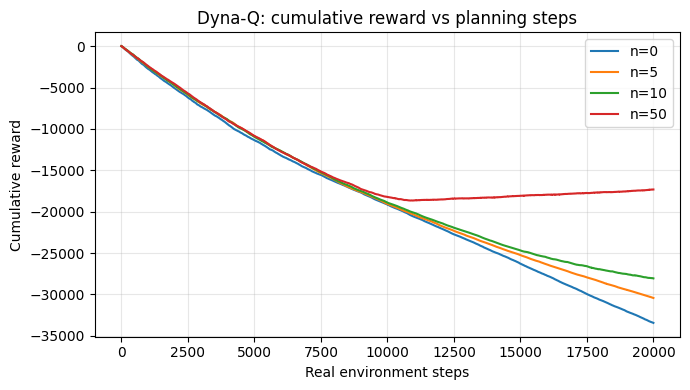

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for n in ns:
    cum = np.cumsum(np.mean(results[n], 0))
    ax.plot(cum, label=f"n={n}")
ax.set_xlabel("Real environment steps")
ax.set_ylabel("Cumulative reward")
ax.set_title("Dyna-Q: cumulative reward vs planning steps")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig1_cum_reward.png", dpi=140)
plt.show()


## Figure 2: episode length vs episode index


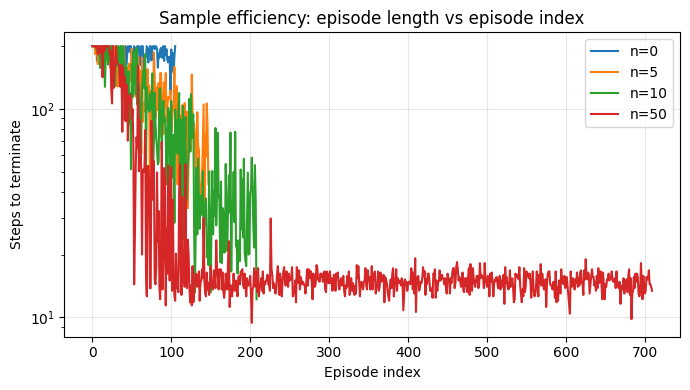

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for n in ns:
    max_eps = min(len(e) for e in ep_results[n])
    arr = np.array([e[:max_eps] for e in ep_results[n]])
    ax.plot(arr.mean(0), label=f"n={n}")
ax.set_xlabel("Episode index")
ax.set_ylabel("Steps to terminate")
ax.set_title("Sample efficiency: episode length vs episode index")
ax.legend(); ax.grid(alpha=0.3); ax.set_yscale("log")
plt.tight_layout(); plt.savefig("fig2_episode_length.png", dpi=140)
plt.show()


## Figure 3: real env steps to first solved episode


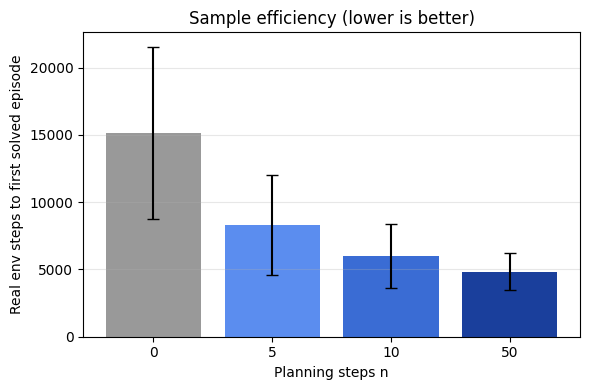

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
means, stds = [], []
for n in ns:
    firsts = []
    for eps in ep_results[n]:
        cs = np.cumsum(eps)
        solved = next((cs[i] for i, L in enumerate(eps) if L <= 20), max(cs))
        firsts.append(solved)
    means.append(np.mean(firsts)); stds.append(np.std(firsts))
ax.bar([str(n) for n in ns], means, yerr=stds, capsize=4,
       color=["#999", "#5b8def", "#3a6cd4", "#1a3f9c"])
ax.set_xlabel("Planning steps n")
ax.set_ylabel("Real env steps to first solved episode")
ax.set_title("Sample efficiency (lower is better)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("fig3_sample_efficiency.png", dpi=140)
plt.show()
